<a href="https://colab.research.google.com/github/pedrosouzag/edicao-imagens-ia/blob/main/semana7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
import cv2 as cv
import numpy as np
import re
import pandas as pd
from datetime import datetime
import os
from google.colab.patches import cv2_imshow


device = "cuda" if torch.cuda.is_available() else "cpu"
print("Usando:", device)

Usando: cpu


In [2]:
# dicionario de operacoes e cores
# operacoes = {"clarear" : "clarear", "escurecer" : "escurecer", "mais claro" : "clarear",
#              "mais escuro" : "escurecer", "mudar cor" : "mudar cor", "mude cor" : "mudar cor",
#               "azul" : "mudar cor", "verde" : "mudar cor", "vermelho" : "mudar cor", "roxo" : "mudar cor", "amarelo" : "mudar cor"}


cor = { "vermelho": 0, "azul": 120,"verde": 60,"amarelo": 30 } # criar outro pra preto, branco e cinza

In [3]:
# procura qual comando foi passado
def discover_command(comand):
  comand_lower = comand.lower()

  if re.search(r"claro|mais claro|clarear", comand_lower):
    return "clarear", None

  elif re.search(r"escuro|mais escuro|escurecer", comand_lower):
    return "escurecer", None

  # procura a cor
  elif re.search(r"mudar cor|mude cor|pinte|troque a cor", comand_lower):
    cor = re.search(r"azul|verde|vermelho|roxo|amarelo|preto|branco|cinza", comand_lower)
    atributo = cor.group() if cor else None
    return "mudar cor", atributo

  return None, None

In [4]:
def alterar_brilho(image, mask, alpha, beta):
  # altera o brilho na imagem
  temp = cv.convertScaleAbs(image, alpha = alpha, beta = beta)

  result = image.copy()

  # copia para a imagem original somente a região que está dentro da máscara
  cv.copyTo(temp, mask, result)
  return result

In [5]:
def alterar_cor(image, mask, valor_cor):
    #  converter para HSV
    hsv = cv.cvtColor(image, cv.COLOR_RGB2HSV)
    # na regiao das mascara, muda a cor
    hsv[:, :, 0][mask > 0] = valor_cor

    # converte para RGB novaamente
    temp = cv.cvtColor(hsv, cv.COLOR_HSV2RGB)

    # copia o que esta na mascara para a imagem original
    result = image.copy()
    cv.copyTo(temp, mask, result)

    return result

In [6]:
def salvar_execucao(image, result, comand, operation, atributo=None, value=None):

    pasta = "resultados"
    # cria a pasta caso nao exista
    os.makedirs(pasta, exist_ok=True)

    # pega a data de agora para por no nome do arquivo
    agora = datetime.now()

    data = agora.strftime("%Y-%m-%d")
    horario = agora.strftime("%H:%M:%S")

    identificador = agora.strftime("%Y%m%d_%H%M%S")

    nome_original = f"original_{identificador}.png"
    nome_resultado = f"resultado_{identificador}.png"

    caminho_original = os.path.join(pasta, nome_original)
    caminho_resultado = os.path.join(pasta, nome_resultado)

    # salva as imagens
    Image.fromarray(image).save(caminho_original)
    Image.fromarray(result).save(caminho_resultado)

    # registro
    registro = {
        "data": agora.strftime("%Y-%m-%d"), "horario": agora.strftime("%H:%M:%S"),"comando": comand,
        "operacao": operation, "atributo": atributo, "valor": value }

    arquivo = "historico.csv"

    # adiciona o registro no arquivo
    if os.path.exists(arquivo):
        df = pd.read_csv(arquivo)
        df = pd.concat([df, pd.DataFrame([registro])], ignore_index=True)
    else:
        df = pd.DataFrame([registro])

    df.to_csv(arquivo, index=False)

In [7]:
image_path = files.upload()
image_filename = list(image_path.keys())[0]
# converte para NumPy
image = np.array(Image.open(image_filename).convert("RGB").resize((512, 512)))

Saving teste.png to teste.png


In [8]:
mask_path = files.upload()
mask_filename = list(mask_path.keys())[0]
# converte para NumPy
mask = np.array(Image.open(mask_filename).convert("L").resize((512, 512)))

Saving mascara_ceu_512.png to mascara_ceu_512.png


In [9]:
# descobrir qual operacao foi pedida na comando

comand = "pinte de azul"
operation, atributo = discover_command(comand)

value = None

if operation == "clarear":
  result = alterar_brilho(image, mask, 1.5, 0)
  edition_type = "brilho"

elif operation == "escurecer":
  result = alterar_brilho(image, mask, 0.5, 0)
  edition_type = "brilho"

elif operation == "mudar cor":
    if atributo in cor:
        value = cor[atributo]
        result = alterar_cor(image, mask, value)
        edition_type = "cor"
    else:
        result = image
        edition_type = "nenhuma"

else:
    print("Erro: comando não reconhecido.")
    result = image
    edition_type = "erro"



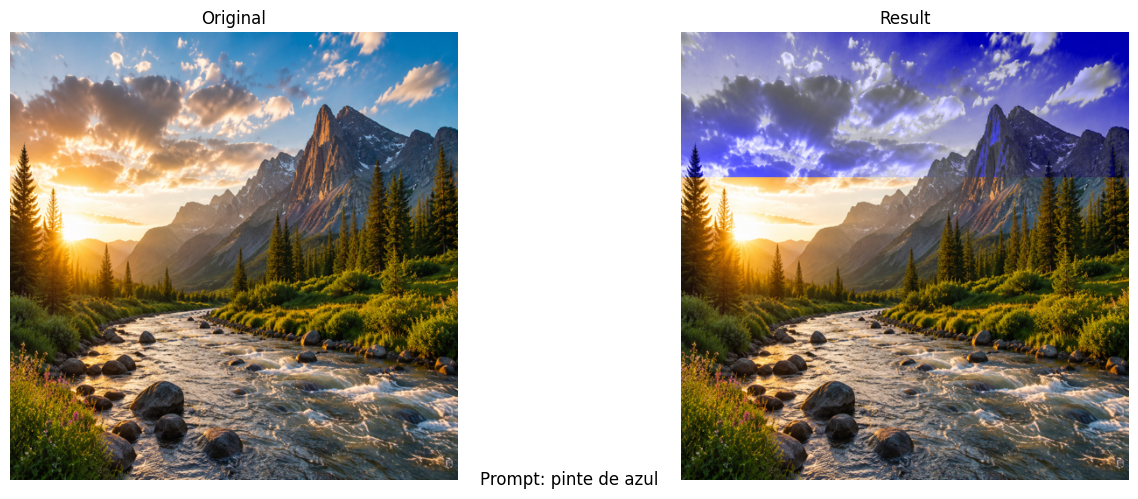

In [10]:
# comparacao entre antes e depois

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].imshow(image)
axs[0].set_title("Original")
axs[0].axis("off")

axs[1].imshow(result)
axs[1].set_title("Result")
axs[1].axis("off")

fig.text(0.5, 0.02, f"Prompt: {comand}", ha="center", fontsize=12)

plt.tight_layout()
plt.savefig("comparacao.png")
plt.show()

In [11]:
# funcao de salvar os metadados
salvar_execucao(image, result, comand, operation, atributo, value)

In [12]:
# import shutil

# if os.path.exists("resultados"):
#     shutil.rmtree("resultados")